# Comparación de algoritmos de Control en Cliff Walking

En este notebook se comparan los siguientes algoritmos de *Reinforcement Learning*:

- Monte Carlo On-Policy
- Monte Carlo Off-Policy
- SARSA
- Q-Learning

Todos los experimentos se realizan en el entorno `CliffWalking-v1` de Gymnasium.

## Imports

In [1]:
!unzip codigo.zip -d ./

Archive:  codigo.zip
   creating: ./environments/
  inflating: ./environments/cliff.py  
   creating: ./policies/
  inflating: ./policies/epsilon_greedy.py  
   creating: ./utils/
  inflating: ./utils/plotting.py     
   creating: ./algorithms/
  inflating: ./algorithms/base.py    
  inflating: ./algorithms/mc_off_policy.py  
  inflating: ./algorithms/mc_on_policy.py  
  inflating: ./algorithms/q_learning.py  
  inflating: ./algorithms/sarsa.py   


In [2]:
import numpy as np
import matplotlib.pyplot as plt

from environments.cliff import make_cliff_env

from algorithms.mc_on_policy import MCOnPolicy
from algorithms.mc_off_policy import MCOffPolicy
from algorithms.sarsa import SARSA
from algorithms.q_learning import QLearning

from utils.plotting import plot_curve, compare_algorithms

In [3]:
def summarize_results(name, rewards):
    print(f"\n=== {name} ===")
    print(f"Máximo: {np.max(rewards):.2f}")
    print(f"Media últimos 100: {np.mean(rewards[-100:]):.2f}")

## Configuración del experimento

Se definen los parámetros comunes a todos los algoritmos.

In [4]:
NUM_EPISODES = 5000
SEED = 100

env = make_cliff_env(seed=SEED)

print("Número de estados:", env.observation_space.n)
print("Número de acciones:", env.action_space.n)

Número de estados: 48
Número de acciones: 4


## Monte Carlo On-Policy (All-Visit)

Entrenando MC on-policy: 100%|██████████| 5000/5000 [04:29<00:00, 18.55it/s]


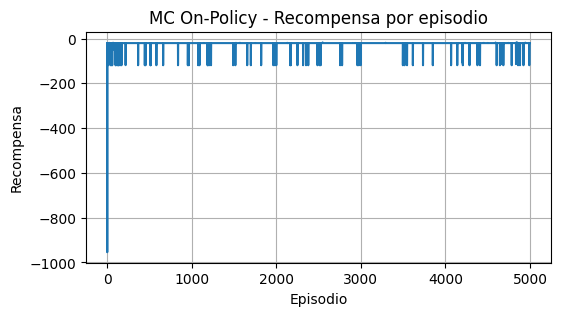

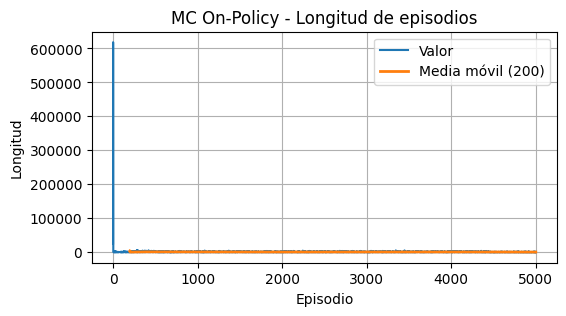

In [5]:
mc_on = MCOnPolicy(
    env,
    epsilon=0.3,
    discount_factor=0.95,
    decay=True
)

mc_on_rewards, mc_on_lengths = mc_on.train(NUM_EPISODES)

plot_curve(
    mc_on_rewards,
    title="MC On-Policy - Recompensa por episodio",
    ylabel="Recompensa"
)

plot_curve(
    mc_on_lengths,
    title="MC On-Policy - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Monte Carlo Off-Policy (Importance Sampling)

Entrenando MC off-policy: 100%|██████████| 5000/5000 [00:14<00:00, 351.09it/s]


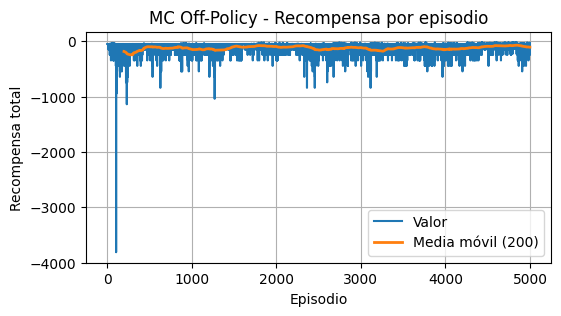

In [6]:
mc_off = MCOffPolicy(
    env,
    discount_factor=0.95,
    epsilon=0.3,
    max_steps=50
)

mc_off_rewards = mc_off.train(NUM_EPISODES)

plot_curve(
    mc_off_rewards,
    title="MC Off-Policy - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

## SARSA (On-Policy TD Control)

Entrenando SARSA: 100%|██████████| 5000/5000 [00:07<00:00, 691.82it/s]


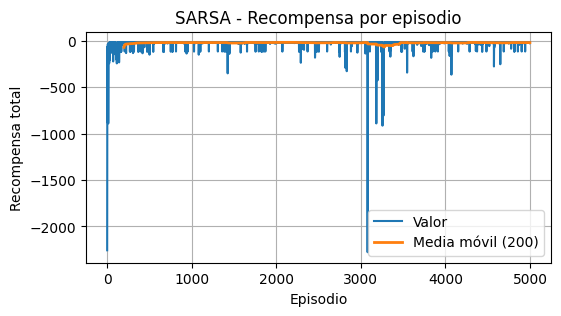

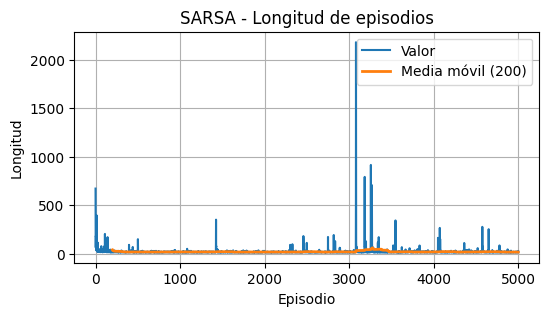

In [7]:
sarsa = SARSA(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=True
)

sarsa_rewards, sarsa_lengths = sarsa.train(NUM_EPISODES)

plot_curve(
    sarsa_rewards,
    title="SARSA - Recompensa por episodio",
    ylabel="Recompensa total",
    moving_avg_window=200
)

plot_curve(
    sarsa_lengths,
    title="SARSA - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Q-Learning (Off-Policy TD Control)

Entrenando Q-Learning: 100%|██████████| 5000/5000 [00:04<00:00, 1093.25it/s]


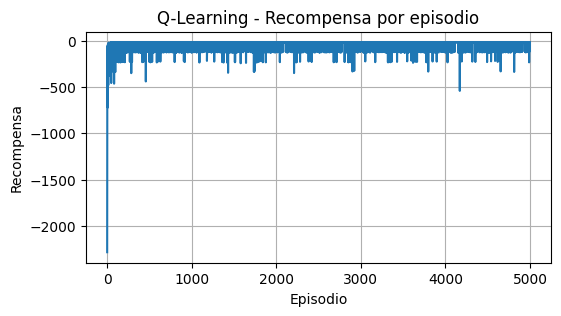

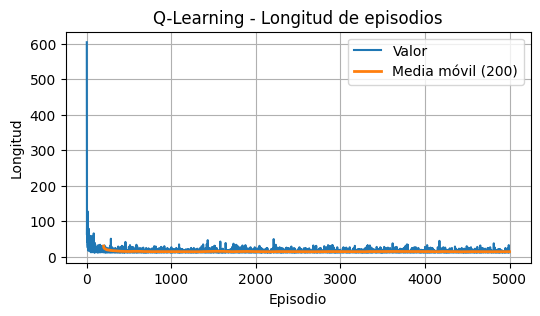

In [8]:
q_learning = QLearning(
    env,
    alpha=0.5,
    discount_factor=0.95,
    epsilon=0.3,
    decay=True
)

q_rewards, q_lengths = q_learning.train(NUM_EPISODES)

plot_curve(
    q_rewards,
    title="Q-Learning - Recompensa por episodio",
    ylabel="Recompensa"
)

plot_curve(
    q_lengths,
    title="Q-Learning - Longitud de episodios",
    ylabel="Longitud",
    moving_avg_window=200
)

## Comparación global de algoritmos

Se comparan las recompensas promedio acumuladas.

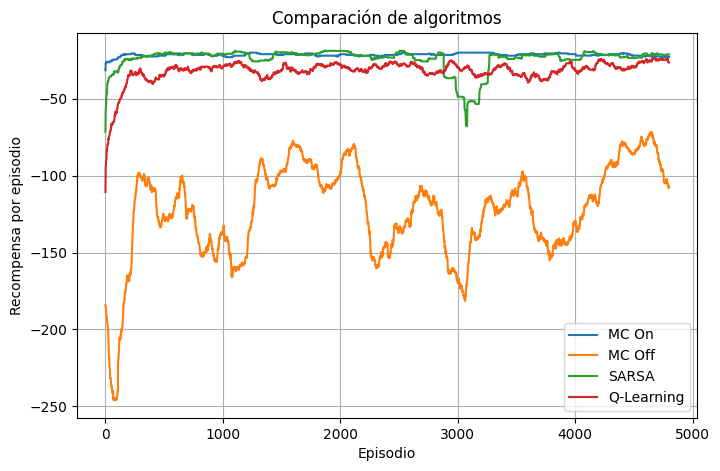

In [9]:
compare_algorithms({
    "MC On": mc_on_rewards,
    "MC Off": mc_off_rewards,
    "SARSA": sarsa_rewards,
    "Q-Learning": q_rewards
}, window=200)

In [10]:
summarize_results("MC Off", mc_off_rewards)
summarize_results("MC On", mc_on_rewards)
summarize_results("SARSA", sarsa_rewards)
summarize_results("Q-Learning", q_rewards)


=== MC Off ===
Máximo: -18.00
Media últimos 100: -124.29

=== MC On ===
Máximo: -16.13
Media últimos 100: -21.93

=== SARSA ===
Máximo: -17.00
Media últimos 100: -20.39

=== Q-Learning ===
Máximo: -13.00
Media últimos 100: -25.40


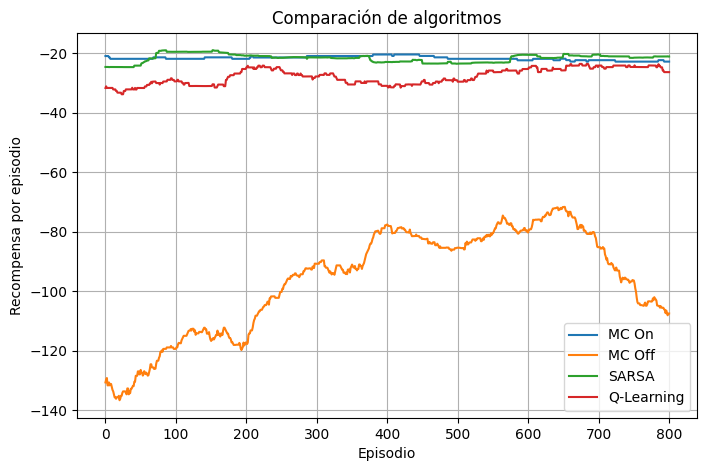

In [11]:
# Últimos 1000 episodios (con media móvil)
compare_algorithms({
    "MC On": mc_on_rewards[-1000:],
    "MC Off": mc_off_rewards[-1000:],
    "SARSA": sarsa_rewards[-1000:],
    "Q-Learning": q_rewards[-1000:]
})

## Política greedy aprendida

Se muestra la política final aprendida por cada algoritmo.

In [12]:
print("Política MC On-Policy:")
print(mc_on.greedy_policy())

print("\nPolítica MC Off-Policy:")
print(mc_off.greedy_policy())

print("\nPolítica SARSA:")
print(sarsa.greedy_policy())

print("\nPolítica Q-Learning:")
print(q_learning.greedy_policy())

Política MC On-Policy:
[0 0 0 1 1 1 2 1 1 1 1 2 0 0 0 0 0 0 1 1 1 1 0 2 0 0 0 0 0 0 3 0 0 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]

Política MC Off-Policy:
[2 1 1 1 1 2 0 2 1 0 1 1 2 0 1 1 0 1 1 1 0 0 0 2 0 1 1 0 0 1 0 1 0 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]

Política SARSA:
[1 1 1 1 1 1 1 1 1 1 1 2 0 0 3 0 0 1 0 0 0 3 0 2 0 3 0 0 0 0 0 0 0 3 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]

Política Q-Learning:
[3 0 0 1 2 1 1 2 1 1 2 2 2 1 1 1 1 1 1 1 1 1 1 2 1 1 1 1 1 1 1 1 1 1 1 2 0
 0 0 0 0 0 0 0 0 0 0 0]


In [17]:
print("Trayectoria MC On:", mc_on.greedy_policy_trajectory())
print("Trayectoria MC Off:", mc_off.greedy_policy_analysis())
print("Trayectoria SARSA:", sarsa.greedy_policy_trajectory())
print("Trayectoria Q-Learning:", q_learning.greedy_policy_trajectory())

## Conclusiones

- MC On-Policy aprende de episodios completos.
- MC Off-Policy utiliza importance sampling.
- SARSA es on-policy y más conservador.
- Q-Learning es off-policy y tiende a converger más rápido.

Se observan diferencias en estabilidad y velocidad de convergencia entre métodos Monte Carlo y métodos TD.